# Evaluación de embeddings v2 (TrajectoryAutoencoder)

Evalúa el embedding comprimido `z` que produce `land2vec.model.TrajectoryAutoencoder`
sobre las mismas 7 zonas out-of-domain de `notebooks/eval_ood_zones.ipynb`, en
cuatro frentes (ver el plan de la v2):

1. **Fidelidad de reconstrucción** por zona y curva de compresión vs. `d`.
2. **Clustering / tipología** de trayectorias sobre `z`.
3. **Probing**: `z` como insumo para predecir clase dominante / transición /
   ecorregión, comparado contra la secuencia cruda one-hot y el estado oculto
   de la v1 (`GPTDecoder.hidden_states()`) promediado.
4. **Visualización** de `z` en 2D (PCA/UMAP).

**Prerrequisito**: este notebook asume que ya corriste el barrido
(`scripts/train_autoencoder.py --sweep dim` y `--sweep secondary`, en Colab con
GPU -- ver el plan) y que existen `models/sweep_dim/d*/`, `models/sweep_secondary/*/`
y el modelo final elegido en `models/autoencoder_v2/`. Si esas carpetas no
existen todavía, las celdas que las usan van a fallar -- correr primero el
barrido.

In [5]:
!git clone https://github.com/gefero/land2vec.git
%cd land2vec
!pip install -e . --quiet

Cloning into 'land2vec'...
remote: Enumerating objects: 613, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 613 (delta 16), reused 38 (delta 7), pack-reused 560 (from 2)
Receiving objects: 100% (613/613), 129.66 MiB | 46.23 MiB/s, done.
Resolving deltas: 100% (249/249), done.
Updating files: 100% (139/139), done.
/content/land2vec/land2vec
  Preparing metadata (setup.py) ... done


In [1]:
import dataclasses
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from land2vec.dataset import SequenceDatasetAutoencoder
from land2vec.tokenizer import Tokenizer
from land2vec.utils import load_config, load_model, compute_metrics

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ZONES = [
    "puna_noa",
    "patagonia_estepa",
    "periurbano_cordoba",
    "ibera",
    "delta_parana",
    "pampa_nucleo",
    "misiones_selva",
]
VALID_LABELS = [i for i in Tokenizer.VOCAB.values() if i != Tokenizer.VOCAB["[UNK]"]]
LABEL_NAMES = [Tokenizer.REVERSE_VOCAB[i] for i in VALID_LABELS]

In [2]:
def load_zone_seqs(zone: str) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / f"id_seqs_text_2000_2022_{zone}.zip")


def load_zone_coords(zone: str) -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / f"lat_long_df_{zone}.zip", usecols=["ID", "latitude", "longitude"])


@torch.inference_mode()
def encode_zone(model, seqs: pd.Series, batch_size: int = 1024) -> np.ndarray:
    "z (N, embed_dim) para todas las secuencias de una zona, en su orden original."
    loader = DataLoader(SequenceDatasetAutoencoder(seqs), shuffle=False, batch_size=batch_size)
    model.eval()
    chunks = [model.encode(x.to(DEVICE)).cpu() for x, _ in loader]
    return torch.cat(chunks).numpy()


@torch.inference_mode()
def reconstruction_metrics(model, seqs: pd.Series, batch_size: int = 1024) -> dict:
    "Accuracy/macro-F1 de reconstrucción (los 23 estados) sobre una zona completa."
    loader = DataLoader(SequenceDatasetAutoencoder(seqs), shuffle=False, batch_size=batch_size)
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        logits = model(x.to(DEVICE))
        all_preds.append(logits.argmax(-1).cpu().reshape(-1))
        all_targets.append(y.reshape(-1))
    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    metrics = compute_metrics(targets, preds, labels=VALID_LABELS)
    metrics["confusion_matrix"] = confusion_matrix(targets, preds, labels=VALID_LABELS, normalize="true")
    return metrics

def had_transition(seq: str) -> bool:
    "True si la secuencia tiene al menos un cambio de estado en los 23 años."
    return len(set(seq.split("-"))) > 1


## 1. Fidelidad de reconstrucción

### 1a. Curva de compresión: reconstrucción out-of-domain vs. `d`

Carga cada modelo del barrido primario (`models/sweep_dim/d*/`) y mide
accuracy/macro-F1 de reconstrucción sobre las 7 zonas out-of-domain (pooled) --
a diferencia del `val_macro_f1` que reporta el barrido (que es in-domain,
sobre el propio split de entrenamiento), esta curva usa el mismo benchmark
held-out que la v1.

100%|██████████| 3344976/3344976 [00:36<00:00, 92215.98it/s] 


d= 12 accuracy=0.9998 macro_f1=0.8994


100%|██████████| 3344976/3344976 [00:34<00:00, 96988.68it/s] 


d= 16 accuracy=0.9995 macro_f1=0.8984


100%|██████████| 3344976/3344976 [00:34<00:00, 98173.97it/s] 


d= 32 accuracy=0.9998 macro_f1=0.8995


100%|██████████| 3344976/3344976 [00:34<00:00, 98020.64it/s] 


d=  4 accuracy=0.9991 macro_f1=0.8977


100%|██████████| 3344976/3344976 [00:35<00:00, 95325.19it/s] 


d=  8 accuracy=0.9997 macro_f1=0.8989


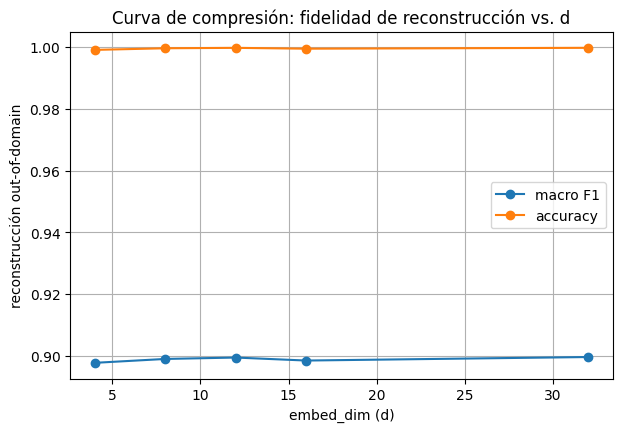

In [9]:
zone_seqs = {zone: load_zone_seqs(zone)["seqs"] for zone in ZONES}
pooled_seqs = pd.concat(zone_seqs.values(), ignore_index=True)

sweep_dim_dir = MODELS_DIR / "sweep_dim"
dim_curve = []
for run_dir in sorted(sweep_dim_dir.glob("d*")):
    config = dataclasses.replace(load_config(run_dir), device=DEVICE)
    model = load_model(config, run_dir).to(DEVICE)
    metrics = reconstruction_metrics(model, pooled_seqs)
    dim_curve.append({"d": config.embed_dim, "accuracy": metrics["accuracy"], "macro_f1": metrics["macro_f1"]})
    print(f"d={config.embed_dim:>3d} accuracy={metrics['accuracy']:.4f} macro_f1={metrics['macro_f1']:.4f}")

dim_curve = pd.DataFrame(dim_curve).sort_values("d")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dim_curve["d"], dim_curve["macro_f1"], marker="o", label="macro F1")
ax.plot(dim_curve["d"], dim_curve["accuracy"], marker="o", label="accuracy")
ax.set_xlabel("embed_dim (d)")
ax.set_ylabel("reconstrucción out-of-domain")
ax.set_title("Curva de compresión: fidelidad de reconstrucción vs. d")
ax.legend()
ax.grid(True)
plt.show()

### 1b. Barrido secundario (lr, n_layer, pooling, pesos de clase) al `d` elegido

In [10]:
sweep_secondary_dir = MODELS_DIR / "sweep_secondary"
secondary_results = []
for run_dir in sorted(sweep_secondary_dir.iterdir()):
    if not run_dir.is_dir():
        continue
    config = dataclasses.replace(load_config(run_dir), device=DEVICE)
    model = load_model(config, run_dir).to(DEVICE)
    metrics = reconstruction_metrics(model, pooled_seqs)
    secondary_results.append({
        "run": run_dir.name, "lr": config.lr, "n_layer": config.n_layer, "pooling": config.pooling,
        "accuracy": metrics["accuracy"], "macro_f1": metrics["macro_f1"],
    })

pd.DataFrame(secondary_results).sort_values("macro_f1", ascending=False)

100%|██████████| 3344976/3344976 [00:34<00:00, 95869.39it/s] 


,run,lr,n_layer,pooling,accuracy,macro_f1
5,n_layer_2_query,0.0010,2,query,0.999864,0.899622
1,lr_bajo,0.0003,4,mean,0.999792,0.899478
2,lr_bajo_n_layer_2,0.0003,2,mean,0.999782,0.899374
0,baseline,0.0010,4,mean,0.999761,0.899317
3,lr_bajo_query,0.0003,4,query,0.999709,0.899264
4,n_layer_2,0.0010,2,mean,0.999742,0.899236
7,sin_pesos,0.0010,4,mean,0.999715,0.899048
6,pooling_query,0.0010,4,query,0.999618,0.898859


### 1c. Modelo final: reconstrucción por zona + matrices de confusión

embed_dim=8 n_layer=2 pooling=query


  0%|          | 0/388800 [00:00<?, ?it/s]

  4%|▍         | 15705/388800 [00:00<00:02, 157032.18it/s]

  8%|▊         | 31908/388800 [00:00<00:02, 159962.60it/s]

 12%|█▏        | 47905/388800 [00:00<00:02, 156721.09it/s]

...

 88%|████████▊ | 343163/388800 [00:02<00:00, 116199.14it/s]

 92%|█████████▏| 359072/388800 [00:02<00:00, 126554.07it/s]

 97%|█████████▋| 376341/388800 [00:02<00:00, 138383.20it/s]

100%|██████████| 388800/388800 [00:02<00:00, 142361.25it/s]

[misiones_selva] accuracy=0.9999 macro_f1=0.6992


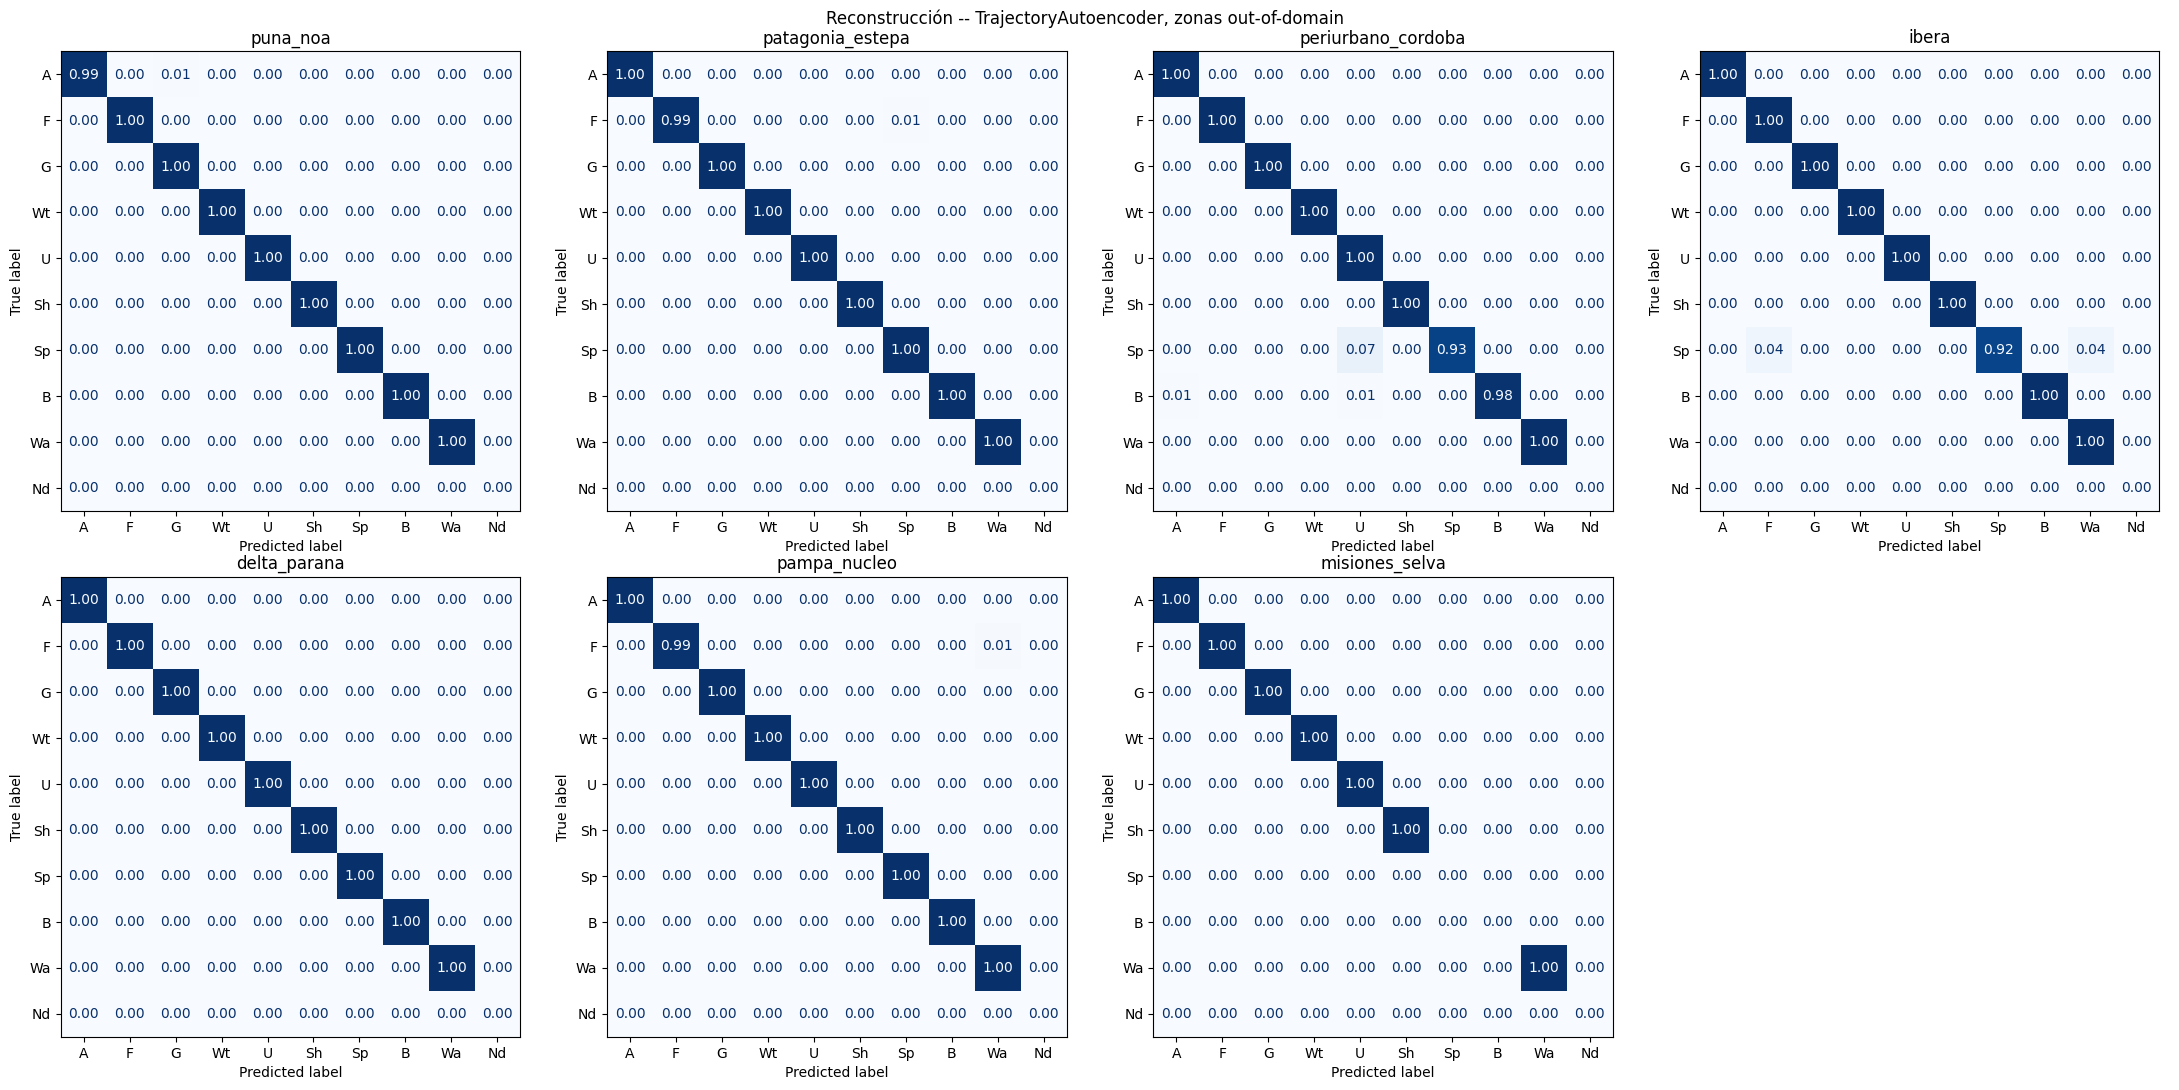

In [4]:
final_config = dataclasses.replace(load_config(MODELS_DIR / "autoencoder_v2"), device=DEVICE)
final_model = load_model(final_config, MODELS_DIR / "autoencoder_v2").to(DEVICE)
print(f"embed_dim={final_config.embed_dim} n_layer={final_config.n_layer} pooling={final_config.pooling}")

zone_results = {}
for zone in ZONES:
    m = reconstruction_metrics(final_model, zone_seqs[zone])
    zone_results[zone] = m
    print(f"[{zone}] accuracy={m['accuracy']:.4f} macro_f1={m['macro_f1']:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for ax, zone in zip(axes.flat, ZONES):
    disp = ConfusionMatrixDisplay(confusion_matrix=zone_results[zone]["confusion_matrix"], display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(zone)
    ax.grid(False)
axes.flat[-1].axis("off")
fig.suptitle("Reconstrucción -- TrajectoryAutoencoder, zonas out-of-domain")
fig.tight_layout()
plt.show()

In [5]:
# Desglose: ¿la reconstrucción es mucho peor específicamente en las secuencias
# con transición? El promedio pooled por zona (celda anterior) puede estar
# dominado por las secuencias constantes (triviales de reconstruir), que son
# mayoría en las zonas de eval (a diferencia del train, submuestreado al 15%).
constant_vs_dynamic = []
for zone in ZONES:
    seqs = zone_seqs[zone]
    mask = seqs.apply(had_transition).values
    for label, subset in [("constante", seqs[~mask]), ("con transición", seqs[mask])]:
        if len(subset) == 0:
            continue
        m = reconstruction_metrics(final_model, subset)
        constant_vs_dynamic.append({
            "zona": zone, "tipo": label, "n": len(subset),
            "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
        })

df_const_dyn = pd.DataFrame(constant_vs_dynamic)
df_const_dyn.pivot(index="zona", columns="tipo", values=["n", "accuracy", "macro_f1"])


  0%|          | 0/358970 [00:00<?, ?it/s]

  4%|▍         | 14077/358970 [00:00<00:02, 140758.05it/s]

  8%|▊         | 28153/358970 [00:00<00:03, 109063.70it/s]

 11%|█▏        | 40864/358970 [00:00<00:02, 116176.18it/s]

 15%|█▌        | 55527/358970 [00:00<00:02, 127145.94it/s]

...

 98%|█████████▊| 366332/373567 [00:02<00:00, 96019.30it/s] 

100%|██████████| 373567/373567 [00:03<00:00, 124516.83it/s]

  0%|          | 0/15233 [00:00<?, ?it/s]

100%|██████████| 15233/15233 [00:00<00:00, 166736.26it/s]

n                  accuracy            \
tipo               con transición  constante con transición constante   
zona                                                                    
delta_parana              11347.0   170093.0       0.996387       1.0   
ibera                     30702.0   260898.0       0.997918       1.0   
misiones_selva            15233.0   373567.0       0.997151       1.0   
pampa_nucleo               7374.0   511026.0       0.989870       1.0   
patagonia_estepa          10770.0  1544430.0       0.986420       1.0   
periurbano_cordoba         2106.0    18630.0       0.994736       1.0   
puna_noa                  29830.0   358970.0       0.995362       1.0   

                         macro_f1            
tipo               con transición constante  
zona                                         
delta_parana             0.773347       0.9  
ibera                    0.794544       0.9  
misiones_selva           0.694544       0.7  
pampa_nucleo             0.887186       0.8  
patagonia_estepa         0.780886       0.9  
periurbano_cordoba       0.887845       0.7  
puna_noa                 0.880432       0.9

## 2. Clustering / tipología de trayectorias

`k=8` con KMeans sobre `z` sin estandarizar fue, en la ronda anterior, una
elección arbitraria -- el silhouette se calculó *después*, como reporte, no
como criterio de selección. Esta sección consume el resultado de
`scripts/tune_clustering.py` (`src/land2vec/cluster.py`): un barrido sobre 4
familias (KMeans, GaussianMixture, HDBSCAN, jerárquico/aglomerativo) x
preprocesado de `z` (crudo / estandarizado / L2), elegidas por un criterio
explícito -- ver `docs/v2_autoencoder_training.md` §7.2 para el detalle
completo:

1. Métricas internas (silhouette, Calinski-Harabasz, Davies-Bouldin).
2. **Estabilidad**: ARI entre reajustes sobre pares de submuestras al 80%
   (bootstrap) -- la defensa contra un `k` que solo se sostiene por el azar
   de la muestra, que la ronda anterior no tenía.
3. **Fidelidad del prototipo**: macro F1 (restringido a clases con
   soporte>0) de comparar cada secuencia real contra la trayectoria
   prototípica decodificada de su cluster -- un cluster solo sirve si su
   prototipo es una descripción honesta de sus miembros, no solo si está
   bien separado.
4. Coherencia espacial vs. una línea de base de etiquetas permutadas.

El jerárquico se ajusta sobre una submuestra estratificada por zona y se
extiende al resto por centroide más cercano (Ward directo sobre las 107k
filas resultó infeasible en el entorno de cómputo -- ver el docstring de
`land2vec.cluster.run_hierarchical_config`).

Corre sobre las secuencias con al menos una transición (3,2% del pool, filtro
ya justificado en la ronda anterior) y, para que el mapa no quede 96,8%
vacío, también etiqueta el pool completo con las constantes submuestreadas
al 15% (`land2vec.cluster.load_pool_subsampled`).

`scripts/tune_clustering.py --select` elige, con el mismo criterio, dos configs: la ganadora sin tope de `k` ("fina") y la mejor con `k_effective <= 20` ("gruesa", pensada para mapas/narrativa en vez de solo precisión) -- ver la comparación más abajo.

**Prerrequisito de esta sección**: correr antes, fuera del notebook,
`python scripts/tune_clustering.py --sweep {kmeans,gmm,hdbscan,hierarchical}`
y `--select` (ver el script para las flags) -- las celdas de abajo leen sus
salidas (`models/cluster_v2/summary.csv`, `chosen.json`,
`data/clusters_dynamic.zip`, `data/clusters_pooled_subsampled.zip`).

In [6]:
pooled_z = np.concatenate([encode_zone(final_model, zone_seqs[zone]) for zone in ZONES])
zone_labels = np.concatenate([[zone] * len(zone_seqs[zone]) for zone in ZONES])
pooled_ids = np.concatenate([load_zone_seqs(zone)["ID"].values for zone in ZONES])

dynamic_mask = pooled_seqs.apply(had_transition).values
print(f"secuencias con transición: {dynamic_mask.sum():,} / {len(dynamic_mask):,} ({dynamic_mask.mean()*100:.1f}%)")

  0%|          | 0/388800 [00:00<?, ?it/s]

  4%|▍         | 15311/388800 [00:00<00:02, 153100.29it/s]

  8%|▊         | 31904/388800 [00:00<00:02, 160638.96it/s]

 12%|█▏        | 47968/388800 [00:00<00:02, 148749.61it/s]

 16%|█▌        | 62940/388800 [00:00<00:02, 142947.81it/s]

...

 91%|█████████ | 352427/388800 [00:02<00:00, 128934.78it/s]

 94%|█████████▍| 366048/388800 [00:02<00:00, 125067.59it/s]

 98%|█████████▊| 381212/388800 [00:03<00:00, 132085.73it/s]

100%|██████████| 388800/388800 [00:03<00:00, 126060.01it/s]

secuencias con transición: 107,362 / 3,344,976 (3.2%)


In [7]:
import json

CLUSTER_DIR = MODELS_DIR / "cluster_v2"
cluster_summary = pd.read_csv(CLUSTER_DIR / "summary.csv")
chosen = json.loads((CLUSTER_DIR / "chosen.json").read_text())
chosen_coarse = json.loads((CLUSTER_DIR / "chosen_coarse.json").read_text())

for label, c in [("fina", chosen), ("gruesa (k<=20)", chosen_coarse)]:
    print(f"--- {label}: {c['algo']} {c['params']} (space={c['space']}, fallback={c['fallback']}) ---")
    for m in ["silhouette_mean", "stability_ari", "prototype_fidelity", "spatial_coherence"]:
        print(f"  {m}: {c['metrics'][m]:.4f}")

elig = cluster_summary[cluster_summary["eligible"]].dropna(subset=["stability_ari", "prototype_fidelity"])
stable = elig[elig["stability_ari"] >= chosen["stability_threshold"]]
ranking_cols = ["run_id", "k_effective", "silhouette_mean", "stability_ari", "prototype_fidelity", "spatial_coherence"]
print(f"\n{len(stable)}/{len(elig)} configs elegibles con stability_ari >= {chosen['stability_threshold']} "
      f"-- top 10 por prototype_fidelity:")
stable[ranking_cols].sort_values("prototype_fidelity", ascending=False).head(10)


--- fina: hdbscan {'min_cluster_size': 250, 'min_samples': None} (space=l2, fallback=False) ---
  silhouette_mean: 0.9135
  stability_ari: 0.9083
  prototype_fidelity: 0.9579
  spatial_coherence: 0.6011
--- gruesa (k<=20): hdbscan {'min_cluster_size': 2500, 'min_samples': 25} (space=l2, fallback=False) ---
  silhouette_mean: 0.5798
  stability_ari: 0.7188
  prototype_fidelity: 0.7398
  spatial_coherence: 0.5950

179/276 configs elegibles con stability_ari >= 0.75 -- top 10 por prototype_fidelity:


,run_id,k_effective,silhouette_mean,stability_ari,prototype_fidelity,spatial_coherence
142,hdbscan__min_cluster_size=250_min_samples=None...,118,0.913456,0.895157,0.957876,0.601077
134,hdbscan__min_cluster_size=250_min_samples=None...,115,0.915943,0.874372,0.954681,0.598578
126,hdbscan__min_cluster_size=250_min_samples=None...,116,0.912326,0.896748,0.950620,0.601091
143,hdbscan__min_cluster_size=250_min_samples=25__...,121,0.865041,0.874803,0.938529,0.596757
127,hdbscan__min_cluster_size=250_min_samples=25__...,119,0.854638,0.900135,0.937334,0.594110
128,hdbscan__min_cluster_size=500_min_samples=None...,62,0.898854,0.896266,0.935595,0.612054
136,hdbscan__min_cluster_size=500_min_samples=None...,63,0.885157,0.905136,0.935338,0.616269
135,hdbscan__min_cluster_size=250_min_samples=25__...,118,0.859900,0.894759,0.932484,0.595280
144,hdbscan__min_cluster_size=500_min_samples=None...,60,0.886144,0.937151,0.924858,0.596466
129,hdbscan__min_cluster_size=500_min_samples=25__...,74,0.794622,0.878747,0.913841,0.618799


### Dos niveles: fino (precisión) vs. grueso (interpretable)

La ganadora sin restricciones es HDBSCAN con `min_cluster_size=250`: k=115
clusters, altísima cohesión (silhouette 0.92) y fidelidad de prototipo
extraordinaria (0.95) -- HDBSCAN no fuerza los puntos "difíciles" a un
cluster (~11% quedan como ruido), así que los clusters que sí forma son muy
homogéneos. Pero 115 tipos no es una tipología legible para un mapa o una
narrativa.

Por eso también se elige, con el mismo criterio pero restringido a
`k_effective <= 20`, una versión "gruesa": HDBSCAN con `min_cluster_size=2500`,
k=12. En el barrido (`n_boot=3`) su estabilidad medía ARI=0.99 -- pasaba
holgado el umbral de 0.75. **Al reajustar con más bootstraps para el número
final (`n_boot=10`, la misma verificación que se le hizo a la fina), la
estabilidad bajó a ARI=0.69, por debajo del umbral.** Esto es exactamente el
tipo de sobreajuste al ruido de una sola corrida que la estabilidad por
bootstrap está pensada para exponer -- confirma que vale la pena
recalcularla con más repeticiones antes de reportar un número final, no solo
en el barrido (`chosen_coarse.json` igual queda con `fallback=false`, porque
esa bandera refleja el criterio de selección con las métricas del barrido, no
el reajuste posterior -- el número que manda acá es el de esta celda).

Se documenta la versión gruesa igual, mostrando ambos números, porque sigue
siendo la mejor opción interpretable disponible y su fidelidad de prototipo
(0.86) y cohesión (silhouette 0.78) siguen siendo buenas -- pero hay que
leerla como una tipología *exploratoria*, no tan firme como la fina. También
tiene más ruido (45% vs. 11% de la fina): con `min_cluster_size` alto, HDBSCAN
deja mucho más territorio sin tipificar antes que forzarlo a uno de los 12
tipos.


In [8]:
def load_level(suffix: str, chosen_cfg: dict) -> dict:
    "Carga y prepara todo lo necesario para describir un nivel de clustering (fino='', grueso='_coarse')."
    dyn_labels_df = pd.read_csv(DATA_DIR / f"clusters_dynamic{suffix}.zip")
    assert len(dyn_labels_df) == dynamic_mask.sum(), (
        f"clusters_dynamic{suffix}.zip no coincide con las secuencias con transición actuales -- "
        "¿hace falta re-correr scripts/tune_clustering.py --select?"
    )
    k = int(dyn_labels_df["cluster"].max()) + 1  # ids 0..k-1, -1 es ruido (HDBSCAN) y no cuenta

    pooled_index_df = pd.DataFrame({"ID": pooled_ids, "zone": zone_labels, "seqs": pooled_seqs.values})
    pooled_index_df["_row"] = np.arange(len(pooled_index_df))
    dyn_with_z = dyn_labels_df.merge(pooled_index_df, on=["ID", "zone"], how="left")
    assert dyn_with_z["_row"].notna().all()
    z_dyn = pooled_z[dyn_with_z["_row"].values.astype(int)]

    pooled_labels_df = pd.read_csv(DATA_DIR / f"clusters_pooled_subsampled{suffix}.zip")

    noise_frac = float((dyn_labels_df["cluster"] == -1).mean())
    return {
        "chosen": chosen_cfg, "k": k, "noise_frac": noise_frac,
        "dyn_labels_df": dyn_labels_df, "dyn_with_z": dyn_with_z, "z_dyn": z_dyn,
        "pooled_labels_df": pooled_labels_df,
    }


levels = {"fina": load_level("", chosen), "gruesa": load_level("_coarse", chosen_coarse)}

for name, lvl in levels.items():
    print(f"--- {name} (k={lvl['k']}, {lvl['noise_frac']*100:.1f}% ruido) ---")
    print(pd.crosstab(lvl["dyn_labels_df"]["cluster"], lvl["dyn_labels_df"]["zone"], normalize="index").round(2))
    print()


--- fina (k=118, 9.8% ruido) ---
zone     delta_parana  ibera  misiones_selva  pampa_nucleo  patagonia_estepa  \
cluster                                                                        
-1               0.04   0.15            0.20          0.11              0.15   
 0               0.00   0.00            0.00          0.00              0.00   
 1               0.27   0.49            0.15          0.00              0.05   
 2               0.10   0.13            0.45          0.21              0.11   
 3               0.92   0.03            0.00          0.05              0.00   
...               ...    ...             ...           ...               ...   
 113             0.00   0.00            0.00          0.00              0.00   
 114             0.00   0.00            0.00          0.00              0.00   
 115             0.00   0.00            0.00          0.00              0.00   
 116             0.00   0.00            0.00          0.00              0.00   
 117   

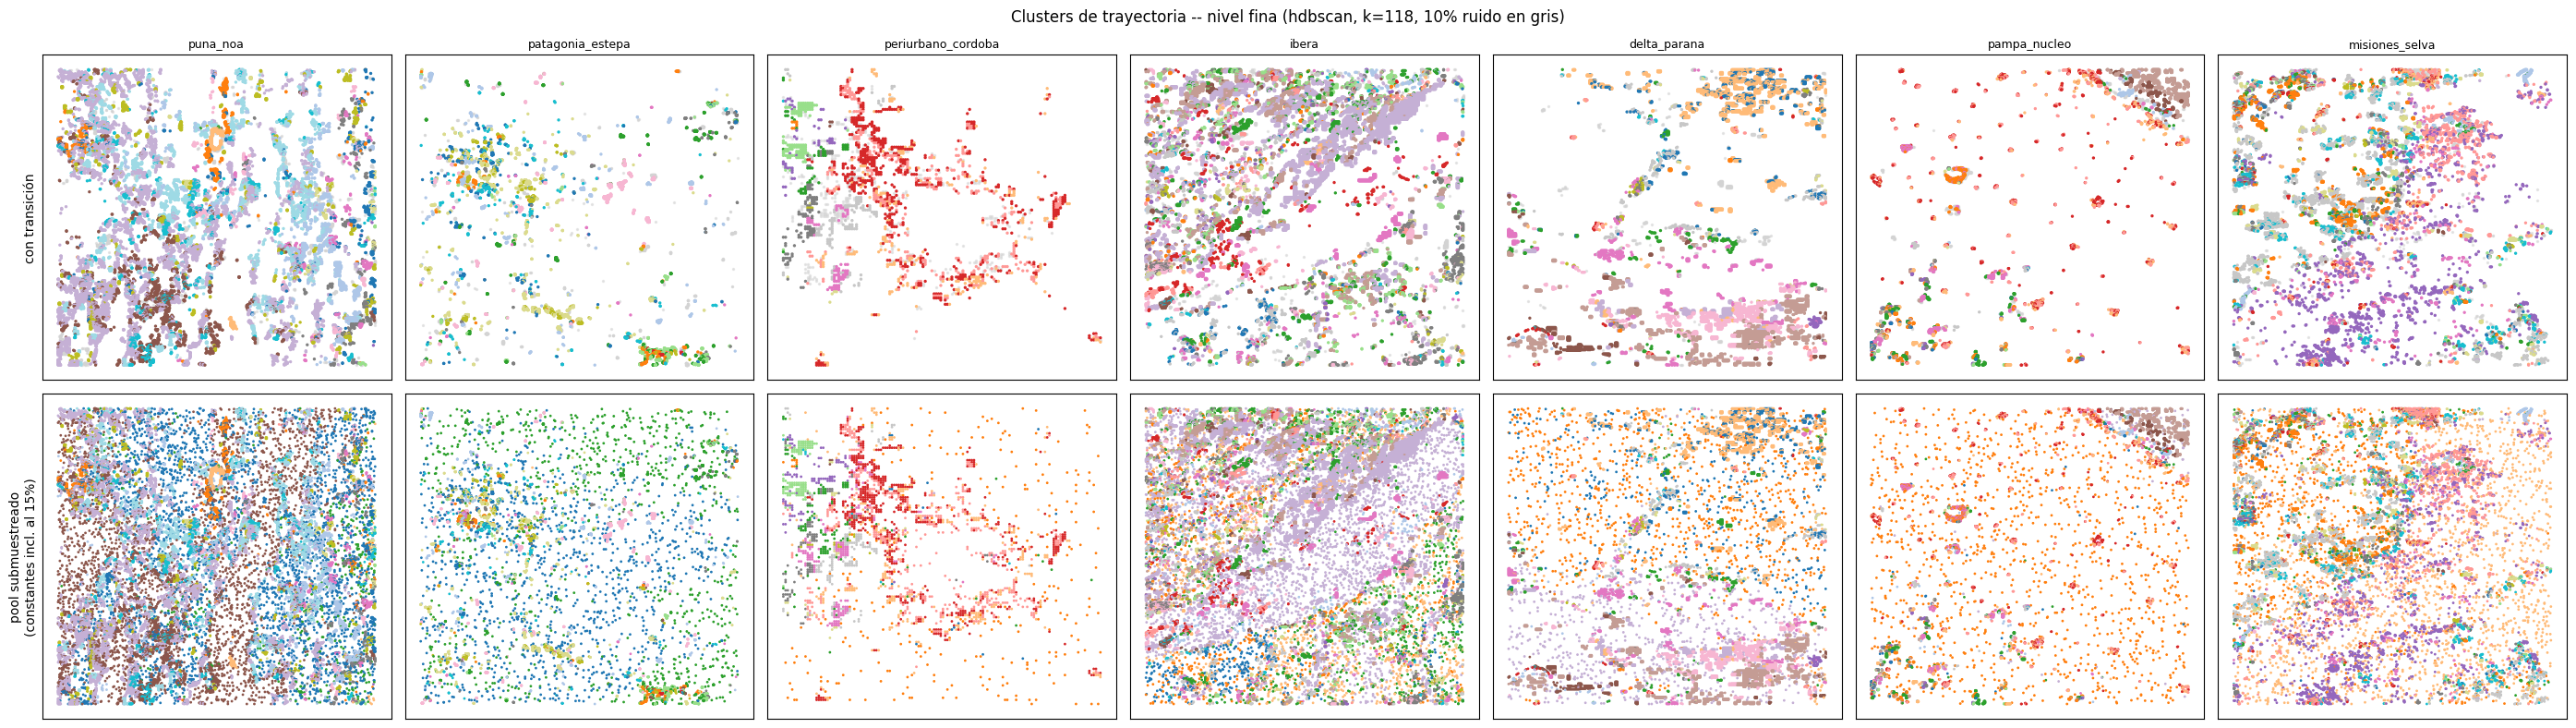

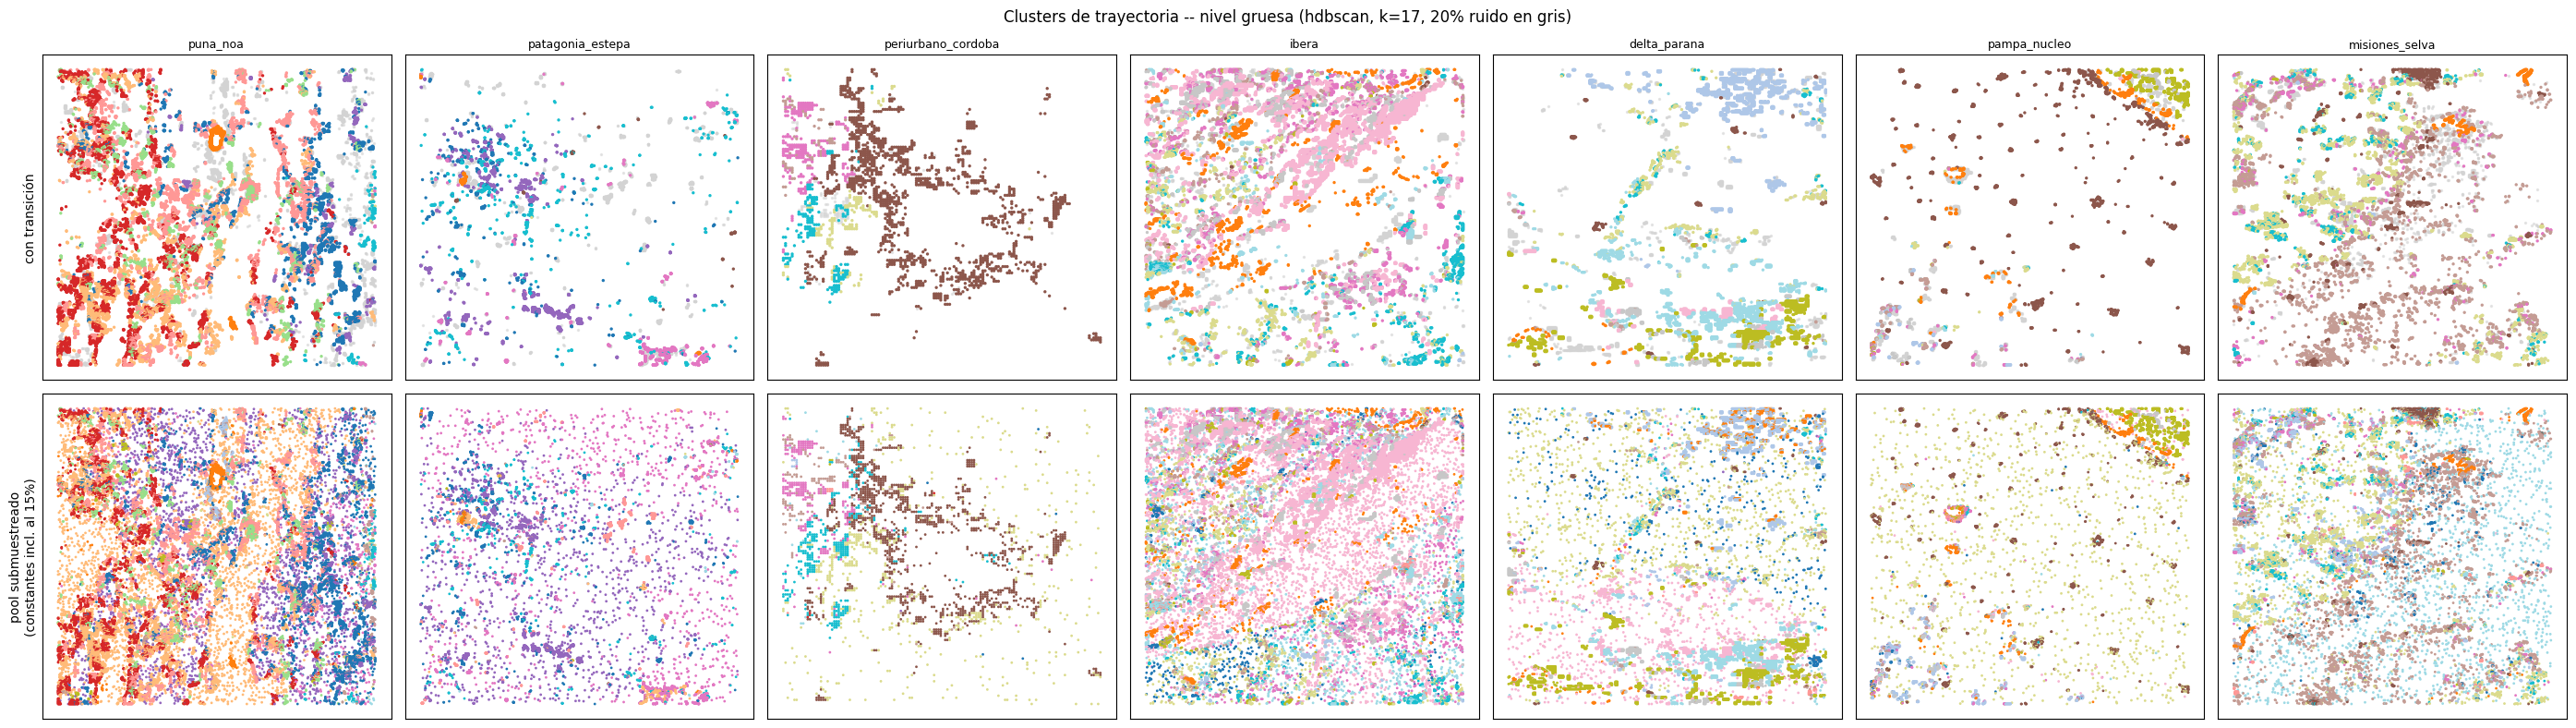

In [9]:
coords = pd.concat([load_zone_coords(zone).assign(zone=zone) for zone in ZONES], ignore_index=True)


def plot_level_map(name: str, lvl: dict) -> None:
    "Dos filas (dinámicas / pool con constantes submuestreadas), un panel por zona. El ruido de HDBSCAN (-1) va en gris, separado del cmap de clusters reales."
    coords_dyn = coords.merge(lvl["dyn_labels_df"], on=["ID", "zone"], how="inner")
    assert len(coords_dyn) == len(lvl["dyn_labels_df"])
    coords_pooled = coords.merge(lvl["pooled_labels_df"], on=["ID", "zone"], how="inner")
    k = lvl["k"]
    cmap = "tab20" if k > 10 else "tab10"

    fig, axes = plt.subplots(2, 7, figsize=(28, 8))
    for col, zone in enumerate(ZONES):
        for row, df in enumerate([coords_dyn, coords_pooled]):
            sub = df[df["zone"] == zone]
            noise = sub[sub["cluster"] == -1]
            clustered = sub[sub["cluster"] != -1]
            point_size = 2 if row == 0 else 1
            axes[row, col].scatter(noise["longitude"], noise["latitude"], c="lightgray", s=point_size, alpha=0.5)
            axes[row, col].scatter(clustered["longitude"], clustered["latitude"], c=clustered["cluster"], cmap=cmap, s=point_size, vmin=0, vmax=k - 1)
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        axes[0, col].set_title(zone, fontsize=9)

    axes[0, 0].set_ylabel("con transición", fontsize=10)
    axes[1, 0].set_ylabel("pool submuestreado\n(constantes incl. al 15%)", fontsize=10)
    fig.suptitle(f"Clusters de trayectoria -- nivel {name} ({lvl['chosen']['algo']}, k={k}, "
                 f"{lvl['noise_frac']*100:.0f}% ruido en gris)")
    fig.tight_layout()
    fig.savefig(Path("imgs") / f"v2_eval_cluster_map_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


for name, lvl in levels.items():
    plot_level_map(name, lvl)


In [10]:
from sklearn.metrics import f1_score


def prototype_table(lvl: dict) -> pd.DataFrame:
    "Por cluster: tamaño, fidelidad del prototipo (macro F1 restringido a clases con soporte>0),\n    la trayectoria prototípica decodificada, y las 3 secuencias reales más cercanas al centroide."
    raw_centers = np.array(lvl["chosen"]["raw_centers"])
    with torch.inference_mode():
        proto_logits = final_model.decode(torch.tensor(raw_centers, dtype=torch.float32, device=DEVICE))
        proto_tokens = proto_logits.argmax(-1).cpu()

    dyn_with_z = lvl["dyn_with_z"]
    z_dyn = lvl["z_dyn"]
    encoded_dyn = np.stack([Tokenizer.encode(s) for s in dyn_with_z["seqs"]])
    cluster_labels = dyn_with_z["cluster"].values

    rows = []
    for cluster_id in range(len(raw_centers)):
        mask = cluster_labels == cluster_id
        n_members = int(mask.sum())
        if n_members == 0:
            continue
        y_true = encoded_dyn[mask].reshape(-1)
        y_pred = np.tile(proto_tokens[cluster_id].numpy(), n_members)
        present = sorted(set(y_true.tolist()) & set(VALID_LABELS))
        fidelity = f1_score(y_true, y_pred, average="macro", labels=present, zero_division=0) if present else float("nan")

        dists = np.linalg.norm(z_dyn[mask] - raw_centers[cluster_id], axis=1)
        nearest_idx = np.argsort(dists)[:3]
        nearest_seqs = dyn_with_z.loc[mask, "seqs"].values[nearest_idx]

        rows.append({
            "cluster": cluster_id, "n": n_members, "prototype_fidelity": round(float(fidelity), 4),
            "prototipo": Tokenizer.decode(proto_tokens[cluster_id]),
            "vecino_real_1": nearest_seqs[0] if len(nearest_seqs) > 0 else None,
            "vecino_real_2": nearest_seqs[1] if len(nearest_seqs) > 1 else None,
            "vecino_real_3": nearest_seqs[2] if len(nearest_seqs) > 2 else None,
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False)


proto_fine = prototype_table(levels["fina"])
print(f"Prototipos -- nivel fino (k={levels['fina']['k']}), 20 más numerosos de {len(proto_fine)}:")
proto_fine.head(20)


Prototipos -- nivel fino (k=118), 20 más numerosos de 118:


,cluster,n,prototype_fidelity,prototipo,vecino_real_1,vecino_real_2,vecino_real_3
54,54,12698,1.0000,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...
55,55,5895,1.0000,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp
69,69,3381,1.0000,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...
23,23,2648,0.9864,Sh-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A,Sh-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A,Sh-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A,Sh-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A
65,65,2557,1.0000,F-F-F-F-F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-F-F-F-F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-F-F-F-F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-F-F-F-F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...
77,77,2204,0.9796,Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-F-F-F-F-F-F-F-F-...,Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-F-F-F-F-F-F-F-F-...,Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-F-F-F-F-F-F-F-F-...,Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-F-F-F-F-F-F-F-F-...
56,56,2147,1.0000,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp
57,57,2104,1.0000,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-S...,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-S...,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-S...,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-S...
113,113,1939,1.0000,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...
12,12,1839,1.0000,F-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A,F-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A,F-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A,F-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A


In [11]:
proto_coarse = prototype_table(levels["gruesa"])
print(f"Prototipos -- nivel grueso (k={levels['gruesa']['k']}), completo:")
proto_coarse


Prototipos -- nivel grueso (k=17), completo:


,cluster,n,prototype_fidelity,prototipo,vecino_real_1,vecino_real_2,vecino_real_3
11,11,12698,1.0000,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...,F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt...
6,6,6828,0.9040,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...,B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-Sp-...
5,5,5895,1.0000,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp-Sp-Sp
10,10,5765,0.5222,F-F-F-F-F-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-...,F-F-F-F-F-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-...,F-F-F-F-F-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-...,F-F-F-F-F-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-...
14,14,5729,0.8047,A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-F-F-F-F-F-F,A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-F-F-F-F-F-F,A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-F-F-F-F-F-F,A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-A-F-F-F-F-F-F
9,9,5510,0.4769,F-F-F-F-F-F-F-F-F-F-F-A-A-A-A-A-A-A-A-A-A-A-A,F-F-F-F-F-F-F-F-F-F-F-A-A-A-A-A-A-A-A-A-A-A-A,F-F-F-F-F-F-F-F-F-F-F-A-A-A-A-A-A-A-A-A-A-A-A,F-F-F-F-F-F-F-F-F-F-F-A-A-A-A-A-A-A-A-A-A-A-A
12,12,5404,0.9635,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...,F-F-F-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-Wt-W...
8,8,4848,0.2160,A-A-A-A-A-A-A-A-A-A-A-U-U-U-U-U-U-U-U-U-U-U-U,A-A-A-A-A-A-A-A-A-A-A-U-U-U-U-U-U-U-U-U-U-U-U,A-A-A-A-A-A-A-A-A-A-A-U-U-U-U-U-U-U-U-U-U-U-U,A-A-A-A-A-A-A-A-A-A-A-U-U-U-U-U-U-U-U-U-U-U-U
3,3,4601,0.8983,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp,B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-B-Sp-Sp
15,15,4552,0.4905,Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-F-F-...,Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-F-F-...,Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-F-F-...,Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-Sh-F-F-...


## 3. Probing: `z` como insumo para otro modelo

Compara tres representaciones como entrada a una regresión logística simple,
sobre tres tareas: clase dominante de la trayectoria, si hubo alguna
transición, y ecorregión (zona) de origen:

- `z` (el embedding de la v2, `embed_dim` dims).
- Secuencia cruda one-hot (23 × 11 = 253 dims) -- el "sin comprimir".
- Estado oculto de la v1 promediado sobre posiciones (128 dims,
  `GPTDecoder.hidden_states(x).mean(dim=1)`) -- ¿aporta el autoencoder algo
  sobre simplemente poolear el modelo que ya existe?

In [16]:
v1_config = dataclasses.replace(load_config(MODELS_DIR / "full_model"), device=DEVICE)
v1_model = load_model(v1_config, MODELS_DIR / "full_model").to(DEVICE)


@torch.inference_mode()
def v1_pooled_hidden(seqs: pd.Series, batch_size: int = 1024) -> np.ndarray:
    "Estado oculto de la v1 (128 dims), promediado sobre las 22 posiciones de contexto."
    loader = DataLoader(SequenceDatasetAutoencoder(seqs), shuffle=False, batch_size=batch_size)
    v1_model.eval()
    chunks = []
    for x, _ in loader:
        h = v1_model.hidden_states(x[:, :-1].to(DEVICE))  # mismo largo de contexto que en entrenamiento (block_size=22)
        chunks.append(h.mean(dim=1).cpu())
    return torch.cat(chunks).numpy()


def one_hot_flat(seqs: pd.Series) -> np.ndarray:
    "Secuencia cruda, one-hot por posición y aplanada (23*11 dims)."
    encoded = np.stack([Tokenizer.encode(s) for s in seqs])
    return np.eye(len(Tokenizer.VOCAB))[encoded].reshape(len(seqs), -1)


pooled_onehot = one_hot_flat(pooled_seqs)
pooled_v1_hidden = np.concatenate([v1_pooled_hidden(zone_seqs[zone]) for zone in ZONES])
print("z:", pooled_z.shape, "one-hot:", pooled_onehot.shape, "v1 hidden:", pooled_v1_hidden.shape)

100%|██████████| 388800/388800 [00:04<00:00, 96113.09it/s] 


z: (3344976, 8) one-hot: (3344976, 253) v1 hidden: (3344976, 128)


In [17]:
def dominant_class(seq: str) -> str:
    return pd.Series(seq.split("-")).mode().iloc[0]


labels_dominant = pooled_seqs.apply(dominant_class).values
labels_transition = pooled_seqs.apply(had_transition).values
labels_zone = zone_labels

representations = {"z (v2)": pooled_z, "one-hot crudo": pooled_onehot, "v1 hidden pooled": pooled_v1_hidden}
tasks = {"clase dominante": labels_dominant, "hubo transición": labels_transition, "ecorregión": labels_zone}

probe_results = []
for task_name, y in tasks.items():
    for repr_name, X in representations.items():
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        acc = clf.score(X_test, y_test)
        probe_results.append({"tarea": task_name, "representación": repr_name, "accuracy": acc})
        print(f"{task_name:18s} | {repr_name:18s} | accuracy={acc:.4f}")

pd.DataFrame(probe_results).pivot(index="tarea", columns="representación", values="accuracy")

clase dominante    | z (v2)             | accuracy=0.9998
clase dominante    | one-hot crudo      | accuracy=0.9999
clase dominante    | v1 hidden pooled   | accuracy=0.9995
hubo transición    | z (v2)             | accuracy=0.9665
hubo transición    | one-hot crudo      | accuracy=0.9926
hubo transición    | v1 hidden pooled   | accuracy=0.9889
ecorregión         | z (v2)             | accuracy=0.7918
ecorregión         | one-hot crudo      | accuracy=0.7992


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ecorregión         | v1 hidden pooled   | accuracy=0.7953


representación,one-hot crudo,v1 hidden pooled,z (v2)
tarea,,,
clase dominante,0.999939,0.999513,0.999813
ecorregión,0.799168,0.795269,0.791761
hubo transición,0.992593,0.988861,0.966532


## 4. Visualización: PCA de `z` a 2D

varianza explicada: [0.5462048  0.21168073] acumulada: 0.7578855


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


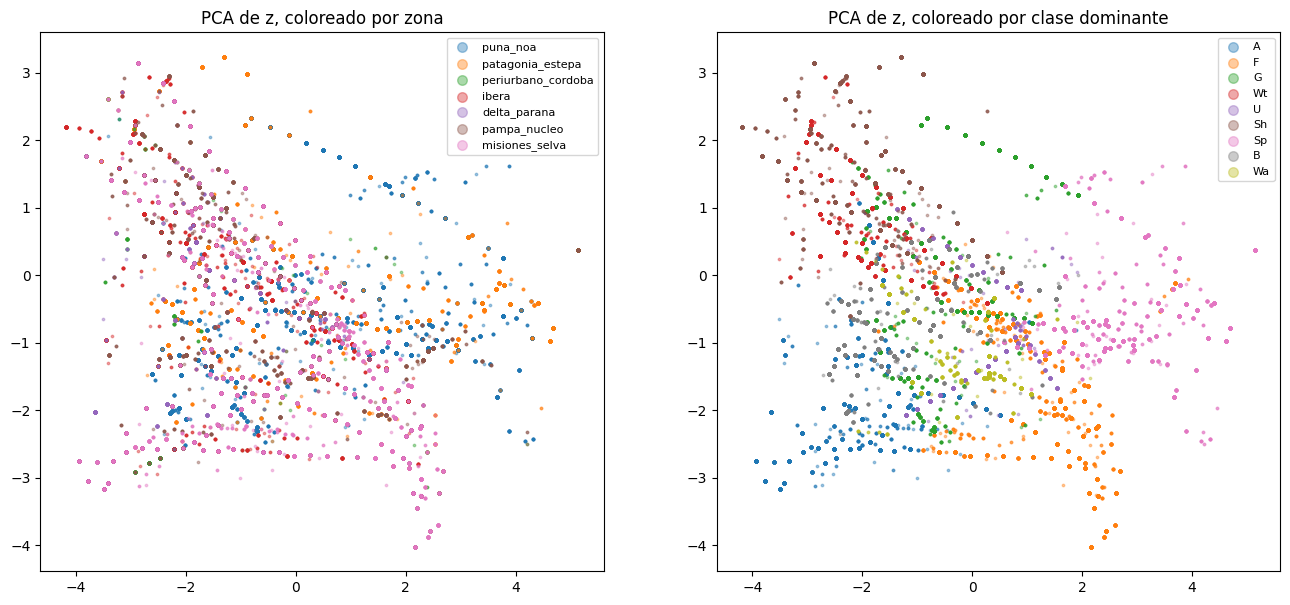

In [18]:
pca = PCA(n_components=2, random_state=42)
z_2d = pca.fit_transform(pooled_z)
print("varianza explicada:", pca.explained_variance_ratio_, "acumulada:", pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for zone in ZONES:
    mask = zone_labels == zone
    axes[0].scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=zone)
axes[0].set_title("PCA de z, coloreado por zona")
axes[0].legend(markerscale=4, fontsize=8)

for token in LABEL_NAMES:
    mask = labels_dominant == token
    if mask.sum() == 0:
        continue
    axes[1].scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=token)
axes[1].set_title("PCA de z, coloreado por clase dominante")
axes[1].legend(markerscale=4, fontsize=8)
plt.show()

## Conclusiones

**Barrido (dim + secundario)**: confirmado sobre datos out-of-domain reales.
`d=8` sigue siendo el codo correcto (macro F1 0.8989 vs. 0.8995 de `d=32`,
4x más dimensiones por +0.0006), y `n_layer_2_query` sigue siendo el mejor
del barrido secundario (0.899622), aunque el margen contra el resto sigue
siendo chico (0.8983-0.8996) -- la elección por eficiencia (mitad de capas,
mitad de tiempo por época) sigue siendo la correcta.

**Hallazgo metodológico importante -- macro F1 por zona no es comparable
entre zonas**: la lectura inicial ("`misiones_selva` es la zona más
difícil", macro F1 0.70 contra 0.86-0.90 del resto) es en gran parte un
artefacto de la métrica, no una diferencia real de calidad de
reconstrucción. Las matrices de confusión por zona (arriba) muestran la
diagonal en ~1.00 en **todas** las clases que efectivamente aparecen en
cada zona -- incluida `misiones_selva`. Lo que pasa es que `compute_metrics`
promedia el F1 sobre las 10 clases del vocabulario completo (fix de una
sesión anterior, para que las comparaciones entre corridas del barrido
fueran justas), y las clases *ausentes* del ground truth de una zona
cuentan como F1=0 en ese promedio (`zero_division=0`). `misiones_selva`
tiene 3 de 10 clases con cero soporte (`Sp`, `B`, `Nd`): `(7×1.0 + 3×0)/10
= 0.70`, exactamente el número reportado. El mismo patrón explica el resto
de las zonas (todas con 9/10 clases presentes, macro F1 ≈0.9 menos el
descuento de la clase ausente). La comparación *entre modelos* del barrido
(misma `pooled_seqs` para todos) no está afectada por este problema --
sigue siendo válida --, pero la comparación *entre zonas* con esta métrica
no lo es. Queda como pendiente (ver más abajo) calcular una versión de
macro F1 restringida a las clases con soporte >0 por zona.

**Constante vs. transición**: accuracy altísima incluso en las secuencias
con transición (0.986-0.998), consistente con la lectura anterior. El
macro F1 más bajo en ese subconjunto (0.69-0.89) está sujeto al mismo
artefacto de vocabulario que el punto anterior -- no se puede leer
directamente como "el modelo reconstruye mal las transiciones".

**Clustering -- reemplazado por un criterio de selección basado en datos**:
la ronda anterior fijaba `k=8` con KMeans sobre `z` sin estandarizar de
forma arbitraria (silhouette 0.43 se calculaba *después*, como reporte, no
como criterio). Esta ronda lo reemplaza por `scripts/tune_clustering.py`: un
barrido sobre 4 familias (KMeans, GaussianMixture, HDBSCAN,
jerárquico/aglomerativo) x preprocesado de `z`, elegidas por estabilidad de
bootstrap (ARI), fidelidad del prototipo decodificado contra sus miembros
reales, y coherencia espacial además de las métricas internas de siempre --
ver `docs/v2_autoencoder_training.md` §7.2 para el criterio completo y el
resultado real de esta corrida (la sección 2 de arriba consume esa salida
directo, no repite los números acá).

**Probing (`z` de 8 dims vs. one-hot crudo de 253 dims vs. hidden state
pooled de la v1, 128 dims)**:

| tarea | z (v2) | one-hot crudo | v1 hidden pooled |
|---|---:|---:|---:|
| clase dominante | 0.9998 | 0.9999 | 0.9995 |
| hubo transición | 0.9665 | 0.9926 | 0.9889 |
| ecorregión | 0.7918 | 0.7992 | 0.7953 |

En 2 de 3 tareas, `z` (16-30x más chico) empata prácticamente con las
representaciones mucho más grandes -- validación fuerte de que la
compresión no tira información relevante para "qué clase domina" ni para
"de qué ecorregión es" (las 3 representaciones tocan el mismo techo de
~80% en ecorregión, probablemente un límite intrínseco de la tarea, no de
`z`). La brecha real está en "hubo transición" (-2.6pp contra el one-hot):
tiene sentido, es la señal más rara (3.2% positivos) y la más fácil de
perder en un cuello de botella de 8 dims optimizado principalmente para
reconstruir la secuencia completa -- el costo de compresión más honesto
que aparece en todo el análisis.

**PCA**: 2 componentes capturan 75.8% de la varianza de `z`. El primer
plano (coloreado por clase dominante) separa grupos con bastante claridad;
coloreado por zona se mezcla mucho más -- consistente con el probing
(clase dominante ~100%, ecorregión ~80%).

### Próximos pasos

1. Calcular una versión de macro F1 restringida a las clases con soporte
   real en cada subconjunto (por zona, o constante/transición), para tener
   una comparación de fidelidad de reconstrucción entre zonas que no esté
   sesgada por cuántas clases del vocabulario aparecen en cada una.
